In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
#load the dataset
df= pd.read_csv("Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2380,3413-DHLPB,Male,0,Yes,Yes,60,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.75,5969.95,No
2468,2636-OHFMN,Male,0,Yes,No,4,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,48.55,201,Yes
4475,4693-VWVBO,Female,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.55,61.05,No
1153,8777-PVYGU,Female,0,Yes,No,52,Yes,No,DSL,Yes,...,Yes,No,Yes,No,One year,Yes,Mailed check,64.30,3410.6,No
5429,9488-FVZCC,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),79.50,5661.7,No


In [3]:
#as customer id is useless lets remove that
df.drop('customerID',axis='columns',inplace=True)
df.dtypes #display columns with datatype

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
#lets change the datatype of TotalCharges from object to number
df.TotalCharges.values
#see they are in string format

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [5]:
#while monthly charges are in correct datatype
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

In [6]:
#pd.to_numeric(df.TotalCharges)--->returns error as some rows have NULL values
#lets check which rows have null values
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
df.shape

(7043, 20)

In [8]:
#integer location
df.iloc[488]
#you can notice the TotalCharges blank here

gender                                 Female
SeniorCitizen                               0
Partner                                   Yes
Dependents                                Yes
tenure                                      0
PhoneService                               No
MultipleLines                No phone service
InternetService                           DSL
OnlineSecurity                            Yes
OnlineBackup                               No
DeviceProtection                          Yes
TechSupport                               Yes
StreamingTV                               Yes
StreamingMovies                            No
Contract                             Two year
PaperlessBilling                          Yes
PaymentMethod       Bank transfer (automatic)
MonthlyCharges                          52.55
TotalCharges                                 
Churn                                      No
Name: 488, dtype: object

In [9]:
df.iloc[488]['TotalCharges']

' '

In [10]:
#lets drop all these rows have null values
df1 = df[df.TotalCharges!=' ']
df1.shape#rows from 7043 to 7032 ..11 rows deleted

(7032, 20)

In [11]:
pd.to_numeric(df1.TotalCharges)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7032, dtype: float64

In [12]:
df1.TotalCharges= pd.to_numeric(df1.TotalCharges)
df1.TotalCharges.dtypes
#now conversion is DONE!!

C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\2451751287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges= pd.to_numeric(df1.TotalCharges)


dtype('float64')

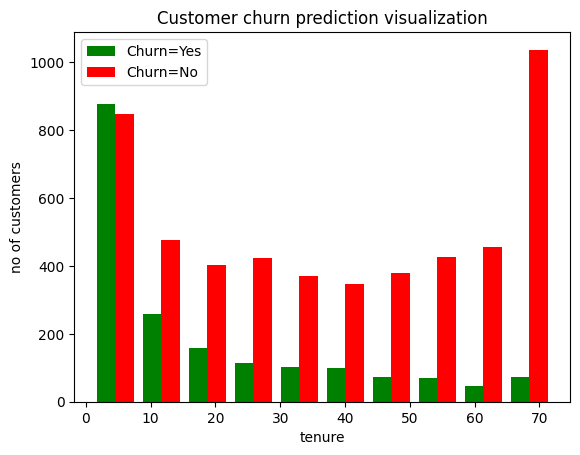

In [13]:
#now lets plot the graph of churn wrt tenure
tenure_churn_no= df1[df1.Churn=='No'].tenure
tenure_churn_yes= df1[df1.Churn=='Yes'].tenure
plt.xlabel("tenure")
plt.ylabel("no of customers")

plt.title("Customer churn prediction visualization")

plt.hist([tenure_churn_yes,tenure_churn_no],color=['green','red'],
         label=['Churn=Yes','Churn=No'])
plt.legend()

In [14]:
#since Many of the columns are yes, no etc. 
#Let's print unique values in object columns to see data values
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}') 

In [15]:
print_unique_col_values(df1)


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [16]:
#Some of the columns have no internet service or no phone service,
#that can be replaced with a simple No
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\402199706.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service','No',inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\402199706.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service','No',inplace=True)


In [17]:
print_unique_col_values(df1)


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [18]:
#Convert Yes and No to 1 or 0(LABEL ENCODING)
 

yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\2899767065.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].replace({'Yes': 1,'No': 0},inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\2899767065.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col].replace({'Yes':

In [19]:
for col in df1:
    print(f'{col}: {df1[col].unique()}') 

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [20]:

df1['gender'].replace({'Female':1,'Male':0},inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\1688734998.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1,'Male':0},inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_116492\1688734998.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].re

In [21]:
df1.gender.unique()


array([1, 0], dtype=int64)

In [22]:
#One hot encoding for categorical columns
df2 = pd.get_dummies(data=df1, 
                     columns=['InternetService','Contract','PaymentMethod'],
                     dtype=int)
df2.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [23]:
df2.sample(5)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4944,0,0,1,1,10,1,1,0,0,0,...,0,0,1,1,0,0,0,0,0,1
1573,0,0,1,1,47,1,0,1,1,1,...,0,1,0,0,1,0,0,0,1,0
2804,0,0,1,0,9,0,0,0,0,0,...,1,0,0,0,1,0,1,0,0,0
6217,0,0,1,1,62,1,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
4360,0,1,1,0,31,1,1,1,0,0,...,0,1,0,1,0,0,0,0,1,0


In [24]:
df2.dtypes


gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int32
InternetService_Fiber optic                  int32
InternetService_No             

In [25]:
df2.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6123,0,0,0,0,65,1,1,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3398,1,0,1,1,61,1,1,1,1,1,...,0,1,0,0,1,0,0,1,0,0
5603,1,0,0,0,1,1,0,1,0,0,...,1,0,0,1,0,0,0,1,0,0
6824,1,1,0,0,66,1,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
2042,1,1,0,0,28,1,1,0,1,1,...,1,0,0,1,0,0,1,0,0,0


In [26]:
#as columns like tenure, MonthlyCharges, TotalCharges have values more than 1
#lets scale them
cols_to_scale= ['tenure','MonthlyCharges','TotalCharges']
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [27]:

for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.         0.46478873 0.01408451 0.61971831 0.09859155 0.29577465
 0.12676056 0.38028169 0.85915493 0.16901408 0.21126761 0.8028169
 0.67605634 0.33802817 0.95774648 0.71830986 0.98591549 0.28169014
 0.15492958 0.4084507  0.64788732 1.         0.22535211 0.36619718
 0.05633803 0.63380282 0.14084507 0.97183099 0.87323944 0.5915493
 0.1971831  0.83098592 0.23943662 0.91549296 0.11267606 0.02816901
 0.42253521 0.69014085 0.88732394 0.77464789 0.08450704 0.57746479
 0.47887324 0.66197183 0.3943662  0.90140845 0.52112676 0.94366197
 0.43661972 0.76056338 0.50704225 0.49295775 0.56338028 0.07042254
 0.04225352 0.45070423 0.92957746 0.30985915 0.78873239 0.84507042
 0.18309859 0.26760563 0.73239437 0.54929577 0.81690141 0.32394366
 0.6056338  0.25352113 0.74647887 0.70422535 0.35211268 0.53521127]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [

In [28]:
#lets prepare train and test datasets
X = df2.drop('Churn',axis='columns')
y = df2['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=5)

In [29]:
X_train.shape


(5625, 26)

In [30]:
X_test.shape


(1407, 26)

In [31]:
X_train[:10]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5664,1,1,0,0,0.126761,1,0,0,0,1,...,0,1,0,1,0,0,0,1,0,0
101,1,0,1,1,0.000000,1,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
2621,0,0,1,0,0.985915,1,0,0,1,1,...,1,0,0,0,0,1,0,1,0,0
392,1,1,0,0,0.014085,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1327,0,0,1,0,0.816901,1,1,0,0,1,...,0,1,0,0,1,0,1,0,0,0
3607,1,0,0,0,0.169014,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2773,0,0,1,0,0.323944,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
1936,1,0,1,0,0.704225,1,0,1,1,0,...,1,0,0,0,1,0,1,0,0,0
5387,0,0,0,0,0.042254,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
4331,0,0,0,0,0.985915,1,1,0,0,0,...,0,0,1,0,0,1,1,0,0,0


In [32]:
len(X_train.columns)

26

In [37]:
#Build a (ANN)model in tensorflow/keras

def ANN(X_train, y_train, X_test, y_test, loss, weights):
    model = keras.Sequential([
        keras.layers.Dense(26, input_dim=26, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    
    if weights == -1:
        model.fit(X_train, y_train, epochs=100)
    else:
        model.fit(X_train, y_train, epochs=100, class_weight = weights)
    
    print(model.evaluate(X_test, y_test))
    
    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)
    
    print("Classification Report: \n", classification_report(y_test, y_preds))
    
    return y_preds

In [40]:
from sklearn.metrics import confusion_matrix , classification_report
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)


Epoch 1/100
176/176 [==============================] - 1s 3ms/step - loss: 0.4993 - accuracy: 0.7557
Epoch 2/100
176/176 [==============================] - 0s 2ms/step - loss: 0.4256 - accuracy: 0.7959
Epoch 3/100
176/176 [==============================] - 0s 3ms/step - loss: 0.4181 - accuracy: 0.8018
Epoch 4/100
176/176 [==============================] - 0s 3ms/step - loss: 0.4139 - accuracy: 0.8053
Epoch 5/100
176/176 [==============================] - 0s 3ms/step - loss: 0.4117 - accuracy: 0.8066
Epoch 6/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4097 - accuracy: 0.8073
Epoch 7/100
176/176 [==============================] - 1s 5ms/step - loss: 0.4083 - accuracy: 0.8123
Epoch 8/100
176/176 [==============================] - 1s 5ms/step - loss: 0.4061 - accuracy: 0.8121
Epoch 9/100
176/176 [==============================] - 1s 5ms/step - loss: 0.4053 - accuracy: 0.8092
Epoch 10/100
176/176 [==============================] - 1s 5ms/step - loss: 0.4035 - accura

Text(95.72222222222221, 0.5, 'Truth')

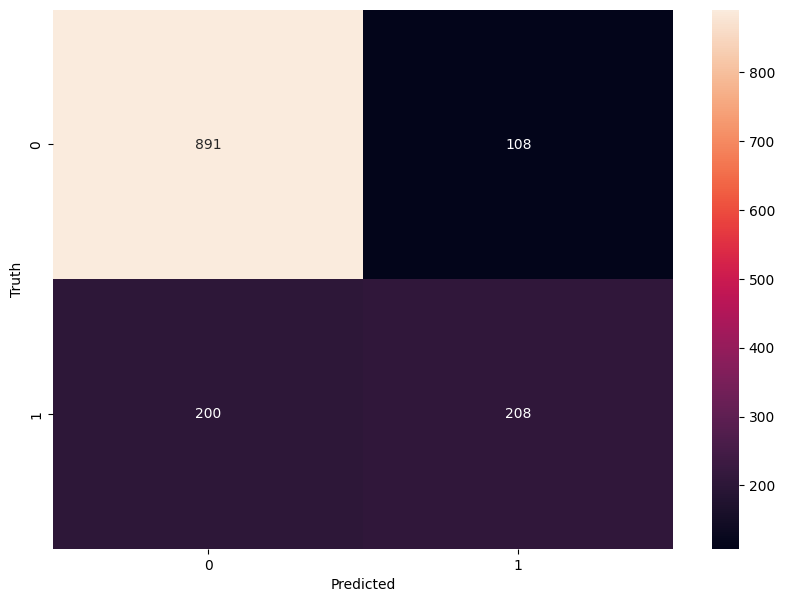

In [43]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_preds)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [44]:
y_test.shape

(1407,)

In [45]:
#Calculating accuracy,precision , recall:
accuracy=round((862+229)/(862+229+137+179),2)
accuracy

0.78

In [46]:
precision_0= round(862/(862+179),2)#Precision for customers who did not churn
precision_1= round(229/(229+137),2)#Precision for customers who actually churned

print(precision_0,precision_1)

0.83 0.63


In [47]:
recall_0= round(862/(862+137),2)
recall_1=round(229/(229+179),2)
print(recall_0,recall_1)

0.86 0.56


In [48]:
#HANDLING IMBALANCED DATASETS!!
#METHOD 1: Undersampling
count_class_0, count_class_1 = df1.Churn.value_counts()

# Divide by class
df_class_0 = df2[df2['Churn'] == 0]
df_class_1 = df2[df2['Churn'] == 1]

In [49]:
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.Churn.value_counts())

Random under-sampling:
Churn
0    1869
1    1869
Name: count, dtype: int64


In [50]:
X = df_test_under.drop('Churn',axis='columns')
y = df_test_under['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15, stratify=y)

In [51]:

# Number of classes in training Data
y_train.value_counts()

Churn
0    1495
1    1495
Name: count, dtype: int64

In [53]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)


Epoch 1/100
94/94 [==============================] - 1s 3ms/step - loss: 0.6274 - accuracy: 0.6569
Epoch 2/100
94/94 [==============================] - 0s 3ms/step - loss: 0.5347 - accuracy: 0.7385
Epoch 3/100
94/94 [==============================] - 0s 3ms/step - loss: 0.5070 - accuracy: 0.7555
Epoch 4/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4964 - accuracy: 0.7585
Epoch 5/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4900 - accuracy: 0.7629
Epoch 6/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4868 - accuracy: 0.7679
Epoch 7/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4837 - accuracy: 0.7679
Epoch 8/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4809 - accuracy: 0.7689
Epoch 9/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4799 - accuracy: 0.7672
Epoch 10/100
94/94 [==============================] - 0s 3ms/step - loss: 0.4796 - accuracy: 0.7702
Epoch 11/

In [54]:
#method: OVERSAMPLING
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.Churn.value_counts())


Random over-sampling:
Churn
0    5163
1    5163
Name: count, dtype: int64


In [55]:
X = df_test_over.drop('Churn',axis='columns')
y = df_test_over['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [56]:
# Number of classes in training Data
y_train.value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

In [57]:
loss = keras.losses.BinaryCrossentropy()
weights = -1
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
259/259 [==============================] - 1s 3ms/step - loss: 0.5735 - accuracy: 0.7155
Epoch 2/100
259/259 [==============================] - 1s 3ms/step - loss: 0.4925 - accuracy: 0.7614
Epoch 3/100
259/259 [==============================] - 1s 3ms/step - loss: 0.4834 - accuracy: 0.7644
Epoch 4/100
259/259 [==============================] - 1s 4ms/step - loss: 0.4786 - accuracy: 0.7690
Epoch 5/100
259/259 [==============================] - 1s 5ms/step - loss: 0.4738 - accuracy: 0.7695
Epoch 6/100
259/259 [==============================] - 1s 4ms/step - loss: 0.4700 - accuracy: 0.7740
Epoch 7/100
259/259 [==============================] - 1s 4ms/step - loss: 0.4672 - accuracy: 0.7760
Epoch 8/100
259/259 [==============================] - 1s 4ms/step - loss: 0.4652 - accuracy: 0.7782
Epoch 9/100
259/259 [==============================] - 1s 5ms/step - loss: 0.4618 - accuracy: 0.7785
Epoch 10/100
259/259 [==============================] - 1s 4ms/step - loss: 0.4590 - accura

In [59]:
#method 3: SMOTE (Synthetic Minority Over-sampling Technique)
#Balance the dataset by creating NEW synthetic samples for the minority 
#class instead of duplicating existing ones.
#SMOTE is not part of sklearn (pip install imbalanced-learn)
X = df2.drop('Churn', axis='columns')
y = df2['Churn']

In [64]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')


In [66]:
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

Churn
0    5163
1    5163
Name: count, dtype: int64

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

In [68]:

# Number of classes in training Data
y_train.value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

In [69]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)


Epoch 1/100
259/259 [==============================] - 1s 2ms/step - loss: 0.5284 - accuracy: 0.7580
Epoch 2/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4681 - accuracy: 0.7769
Epoch 3/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4621 - accuracy: 0.7817
Epoch 4/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4570 - accuracy: 0.7839
Epoch 5/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4532 - accuracy: 0.7873
Epoch 6/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4493 - accuracy: 0.7884
Epoch 7/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4464 - accuracy: 0.7906
Epoch 8/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4413 - accuracy: 0.7904
Epoch 9/100
259/259 [==============================] - 1s 2ms/step - loss: 0.4363 - accuracy: 0.7930
Epoch 10/100
259/259 [==============================] - 0s 2ms/step - loss: 0.4322 - accura

In [70]:
#Method 4: ENSEMBLE WITH UNDERSAMPLING
#trains multiple models on different balanced subsets created by
#combining all minority samples with different chunks of majority samples,
#improving generalization without data loss
df2.Churn.value_counts()


Churn
0    5163
1    1869
Name: count, dtype: int64

In [71]:

# Regain Original features and labels
X = df2.drop('Churn',axis='columns')
y = df2['Churn']

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15, stratify=y)

In [73]:
y_train.value_counts()


Churn
0    4130
1    1495
Name: count, dtype: int64

In [74]:
#model1 --> class1(1495) + class0(0, 1495)

#model2 --> class1(1495) + class0(1496, 2990)

#model3 --> class1(1495) + class0(2990, 4130)

df3 = X_train.copy()
df3['Churn'] = y_train
df3.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
684,1,0,0,0,0.000000,1,0,0,0,0,...,1,0,1,0,0,0,0,0,1,0
2446,1,0,0,0,0.239437,1,1,0,1,0,...,1,0,1,0,0,0,1,0,0,1
1680,0,0,1,1,0.774648,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
2220,0,0,1,0,1.000000,1,0,1,1,0,...,0,0,0,0,1,1,0,0,0,0
2842,1,0,0,0,0.042254,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,0


In [75]:

df3_class0 = df3[df3.Churn==0]
df3_class1 = df3[df3.Churn==1]

In [76]:

def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority], axis=0)

    X_train = df_train.drop('Churn', axis='columns')
    y_train = df_train.Churn
    return X_train, y_train  

In [77]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1495)

y_pred1 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
94/94 [==============================] - 0s 1ms/step - loss: 0.6271 - accuracy: 0.6890
Epoch 2/100
94/94 [==============================] - 0s 2ms/step - loss: 0.5175 - accuracy: 0.7615
Epoch 3/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4933 - accuracy: 0.7649
Epoch 4/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4864 - accuracy: 0.7706
Epoch 5/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4821 - accuracy: 0.7732
Epoch 6/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4802 - accuracy: 0.7783
Epoch 7/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4779 - accuracy: 0.7763
Epoch 8/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4766 - accuracy: 0.7783
Epoch 9/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4737 - accuracy: 0.7806
Epoch 10/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4748 - accuracy: 0.7799
Epoch 11/

In [78]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1495, 2990)

y_pred2 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
94/94 [==============================] - 0s 1ms/step - loss: 0.6447 - accuracy: 0.6348
Epoch 2/100
94/94 [==============================] - 0s 2ms/step - loss: 0.5517 - accuracy: 0.7515
Epoch 3/100
94/94 [==============================] - 0s 2ms/step - loss: 0.5072 - accuracy: 0.7552
Epoch 4/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4928 - accuracy: 0.7609
Epoch 5/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4857 - accuracy: 0.7615
Epoch 6/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4819 - accuracy: 0.7619
Epoch 7/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4787 - accuracy: 0.7642
Epoch 8/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4770 - accuracy: 0.7686
Epoch 9/100
94/94 [==============================] - 0s 2ms/step - loss: 0.4754 - accuracy: 0.7669
Epoch 10/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4731 - accuracy: 0.7702
Epoch 11/

In [79]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2990, 4130)

y_pred3 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
83/83 [==============================] - 0s 1ms/step - loss: 0.6245 - accuracy: 0.6516
Epoch 2/100
83/83 [==============================] - 0s 2ms/step - loss: 0.5289 - accuracy: 0.7438
Epoch 3/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4983 - accuracy: 0.7552
Epoch 4/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4852 - accuracy: 0.7685
Epoch 5/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4794 - accuracy: 0.7734
Epoch 6/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4765 - accuracy: 0.7776
Epoch 7/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4736 - accuracy: 0.7765
Epoch 8/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4705 - accuracy: 0.7784
Epoch 9/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4677 - accuracy: 0.7791
Epoch 10/100
83/83 [==============================] - 0s 2ms/step - loss: 0.4676 - accuracy: 0.7844
Epoch 11/

In [80]:
len(y_pred1)

1407

In [81]:

y_pred_final = y_pred1.copy()
for i in range(len(y_pred1)):
    n_ones = y_pred1[i] + y_pred2[i] + y_pred3[i]
    if n_ones>1:
        y_pred_final[i] = 1
    else:
        y_pred_final[i] = 0

In [82]:

cl_rep = classification_report(y_test, y_pred_final)
print(cl_rep)

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407

